# Import Correlation Matrices
Load all correlation matrices from the correlation_matrices_all_subjects folder

In [1]:
import pandas as pd
import os
from pathlib import Path

# Define the path to the correlation matrices folder
matrices_folder = 'correlation_matrices_all_subjects'

# Load all correlation matrices
correlation_matrices = {}
for filename in sorted(os.listdir(matrices_folder)):
    if filename.endswith('.csv'):
        file_path = os.path.join(matrices_folder, filename)
        # Extract subject and session info from filename
        subject_session = filename.replace('_correlation_matrix_avg.csv', '')
        correlation_matrices[subject_session] = pd.read_csv(file_path, index_col=0)

print(f"Loaded {len(correlation_matrices)} correlation matrices")
print("Subjects loaded:", list(correlation_matrices.keys())[:5], "...")

Loaded 125 correlation matrices
Subjects loaded: ['sub-NORB00001_ses-1', 'sub-NORB00003_ses-1', 'sub-NORB00005_ses-1', 'sub-NORB00006_ses-1', 'sub-NORB00007_ses-1'] ...


## Calculate Jaccard Index (Min/Max Formula) for All Edge Pairs
For each edge pair (e.g., F3-PZ), calculate the Jaccard index between all pairs of subject-sessions using: J(A,B) = min(A,B) / max(A,B)

In [2]:
import numpy as np
from itertools import combinations

# Get all unique edge pairs from the first correlation matrix
first_matrix = list(correlation_matrices.values())[0]
edge_pairs = list(combinations(first_matrix.index, 2))
print(f"Total unique edge pairs: {len(edge_pairs)}")
print(f"Sample edge pairs: {edge_pairs[:5]}")

# Calculate Jaccard index for all edge pairs between all subject-session pairs
subject_sessions = list(correlation_matrices.keys())
num_subjects = len(subject_sessions)

# Create a dictionary to store Jaccard indices for each edge pair
jaccard_indices = {}

for edge_pair in edge_pairs:
    region1, region2 = edge_pair
    # Extract correlation values for this edge pair across all subject-sessions
    edge_values = {}
    for subject_session, matrix in correlation_matrices.items():
        if region1 in matrix.index and region2 in matrix.columns:
            edge_values[subject_session] = matrix.loc[region1, region2]
    
    # Calculate Jaccard index (min/max) between all pairs of subject-sessions
    jaccard_for_edge = {}
    for subject_pair in combinations(subject_sessions, 2):
        ss1, ss2 = subject_pair
        val1 = edge_values.get(ss1)
        val2 = edge_values.get(ss2)
        
        if val1 is not None and val2 is not None:
            # Jaccard index using min/max formula
            jaccard_idx = min(val1, val2) / max(val1, val2) if max(val1, val2) != 0 else 0
            jaccard_for_edge[subject_pair] = jaccard_idx
    
    jaccard_indices[edge_pair] = jaccard_for_edge

print(f"\nCalculated Jaccard indices for {len(jaccard_indices)} edge pairs")
print(f"Number of subject-session pairs: {len(list(combinations(subject_sessions, 2)))}")
print(f"Sample Jaccard values for first edge pair {edge_pairs[0]}: {list(list(jaccard_indices.values())[0].items())[:3]}")

Total unique edge pairs: 171
Sample edge pairs: [('Fp1', 'Fp2'), ('Fp1', 'F3'), ('Fp1', 'F4'), ('Fp1', 'C3'), ('Fp1', 'C4')]

Calculated Jaccard indices for 171 edge pairs
Number of subject-session pairs: 7750
Sample Jaccard values for first edge pair ('Fp1', 'Fp2'): [(('sub-NORB00001_ses-1', 'sub-NORB00003_ses-1'), np.float64(0.9638087438215908)), (('sub-NORB00001_ses-1', 'sub-NORB00005_ses-1'), np.float64(0.9623589973851109)), (('sub-NORB00001_ses-1', 'sub-NORB00006_ses-1'), np.float64(0.9164293609741251))]


## Session 1 Jaccard Index Heatmap for Multi-Session Subjects
Create a heatmap comparing Session 1 Jaccard indices between subject pairs that both have multiple sessions

Subjects with multiple sessions: 21
Multi-session subjects: ['sub-NORB00064', 'sub-NORB00065', 'sub-NORB00069', 'sub-NORB00070', 'sub-NORB00074', 'sub-NORB00075', 'sub-NORB00077', 'sub-NORB00078', 'sub-NORB00079', 'sub-NORB00080']
Subject pairs with both having multiple sessions: 210

Heatmap shape: (210, 171)
Valid subject pairs used: 210
Smallest age difference: 0.0000
Largest age difference: 0.2070


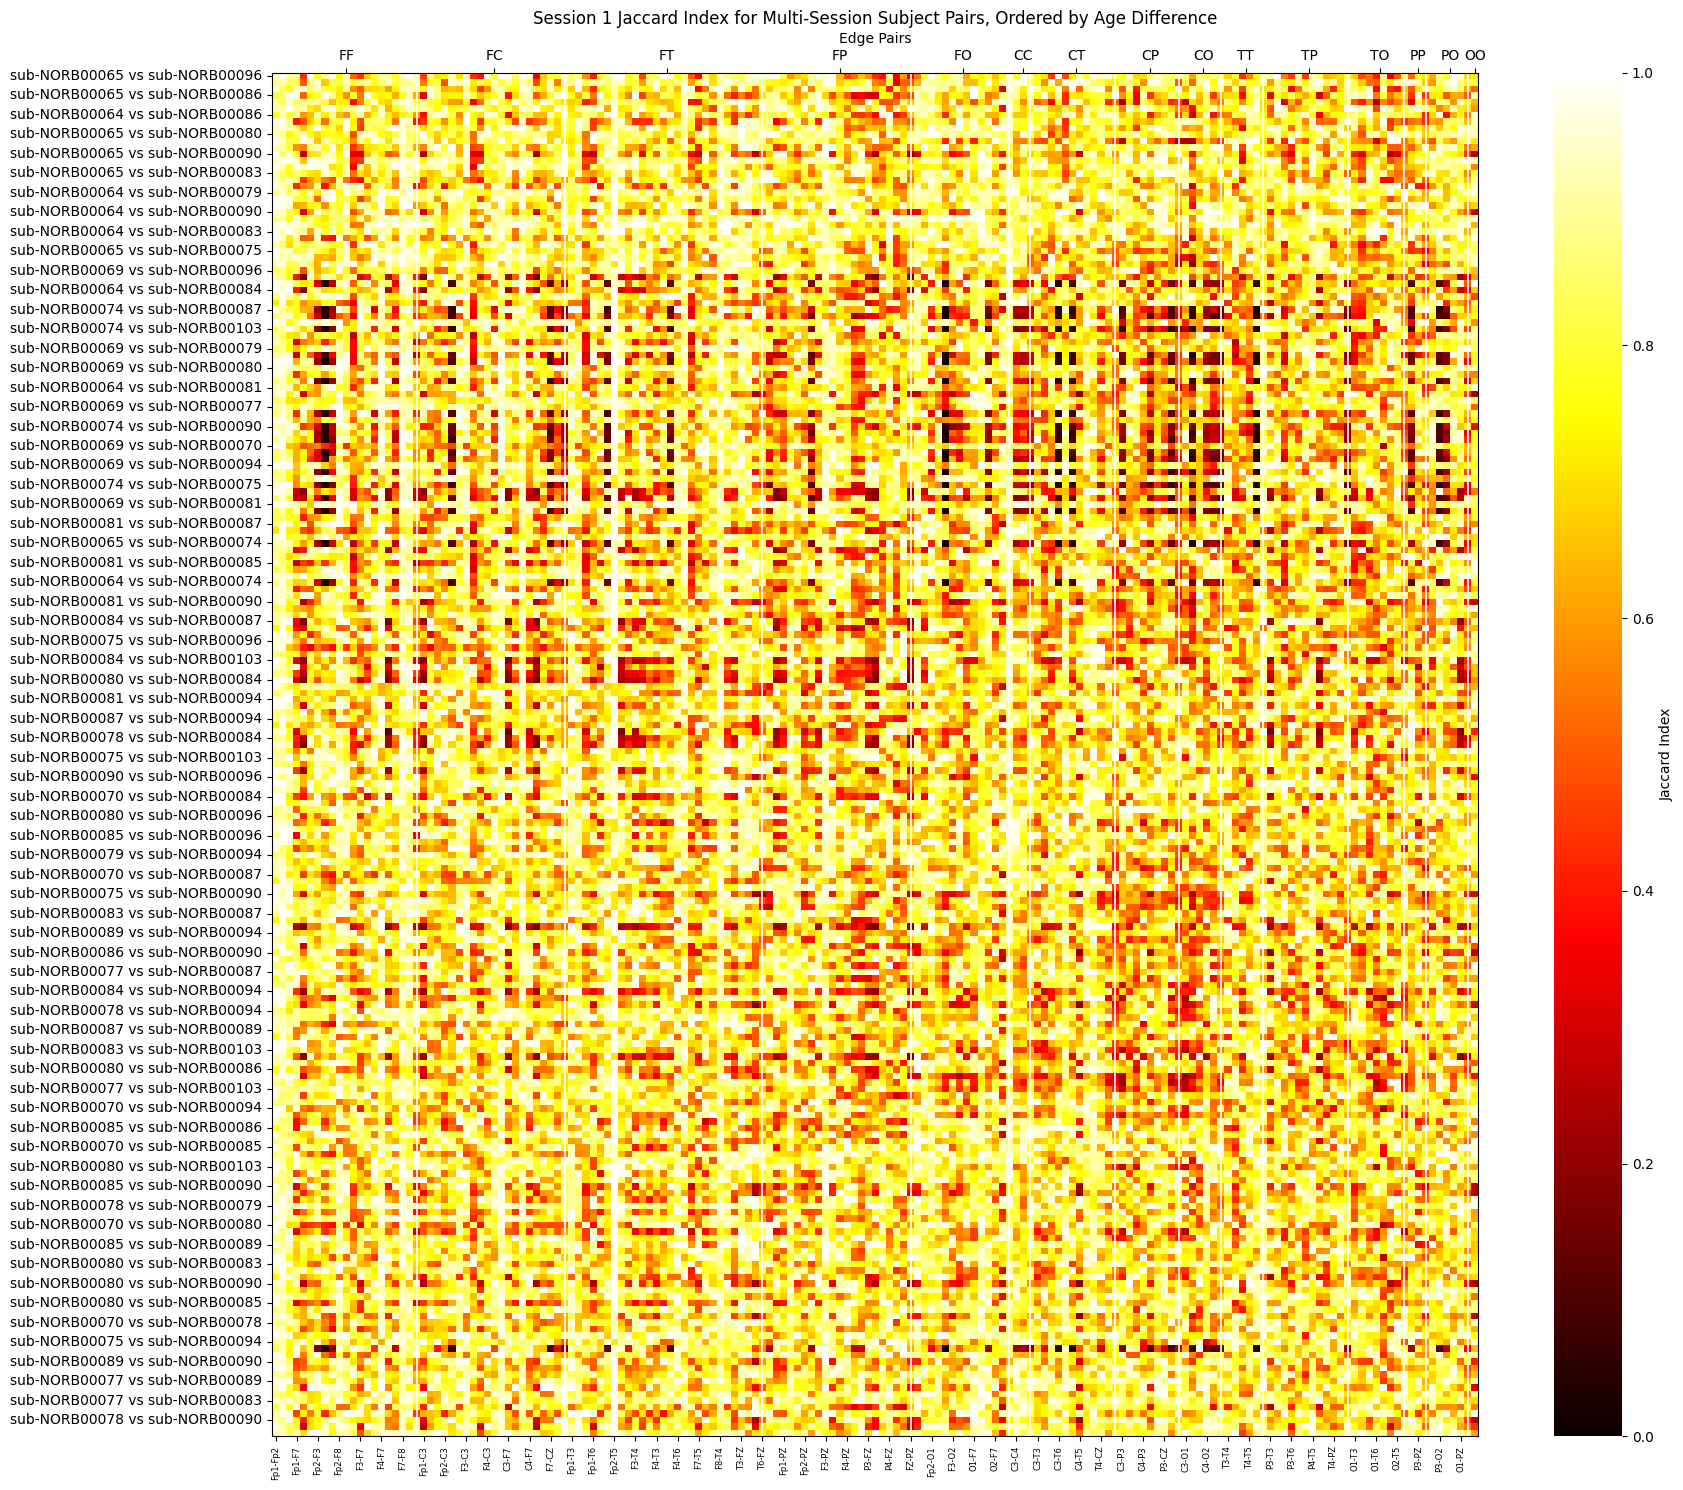


Heatmap created with 210 subject pairs and 171 edge pairs


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load ages for each subject-session from the attached CSV file
age_df = pd.read_csv('age_acq_time_sorted.csv')
age_lookup = dict(zip(age_df['label'], age_df['age_acq_time']))

# Extract subject IDs and sessions from the subject_sessions keys
subject_sessions_dict = {}
for ss in subject_sessions:
    parts = ss.split('_ses-')
    subject_id = parts[0]
    session = int(parts[1]) if len(parts) > 1 else 1

    if subject_id not in subject_sessions_dict:
        subject_sessions_dict[subject_id] = []
    subject_sessions_dict[subject_id].append(session)

# Keep only subjects with more than one session
multi_session_subjects = [subj for subj, sessions in subject_sessions_dict.items() if len(sessions) > 1]
print(f"Subjects with multiple sessions: {len(multi_session_subjects)}")
print(f"Multi-session subjects: {multi_session_subjects[:10]}")

# Build subject pairs where both subjects have more than one session
multi_session_pairs = list(combinations(multi_session_subjects, 2))
print(f"Subject pairs with both having multiple sessions: {len(multi_session_pairs)}")

# Collect Session 1 Jaccard values and age differences for each valid subject pair
session1_pairs_by_age = []
for sub1, sub2 in multi_session_pairs:
    ss1_key = f"{sub1}_ses-1"
    ss2_key = f"{sub2}_ses-1"

    if ss1_key not in subject_sessions or ss2_key not in subject_sessions:
        continue

    age1 = age_lookup.get(ss1_key)
    age2 = age_lookup.get(ss2_key)
    if age1 is None or age2 is None:
        continue

    age_difference = abs(age1 - age2)
    row_values = []
    valid_edge_count = 0

    for edge_pair in edge_pairs:
        pair_values = jaccard_indices.get(edge_pair, {})
        if (ss1_key, ss2_key) in pair_values:
            jaccard_val = pair_values[(ss1_key, ss2_key)]
        elif (ss2_key, ss1_key) in pair_values:
            jaccard_val = pair_values[(ss2_key, ss1_key)]
        else:
            jaccard_val = np.nan

        row_values.append(jaccard_val)
        if not np.isnan(jaccard_val):
            valid_edge_count += 1

    if valid_edge_count:
        session1_pairs_by_age.append(
            {
                'pair_label': f"{sub1} vs {sub2}",
                'age_difference': age_difference,
                'values': row_values,
            }
        )

# Sort edge pairs by the requested band order: FF, FC, FT, FP, FO, CC, CT, CP, CO, TT, TP, TO, PP, PO, OO
band_order = ['F', 'C', 'T', 'P', 'O']
edge_order_map = {}
for i, band_a in enumerate(band_order):
    for band_b in band_order[i:]:
        edge_order_map[f"{band_a}{band_b}"] = len(edge_order_map)


def band_key_for_edge(edge_pair):
    a, b = edge_pair
    ba = a[0].upper()
    bb = b[0].upper()
    # sort letters by band_order to make consistent keys (e.g., FC and CF -> FC)
    key = ''.join(sorted((ba, bb), key=lambda band: band_order.index(band)))
    return key

sorted_edge_pairs = sorted(edge_pairs, key=lambda ep: edge_order_map.get(band_key_for_edge(ep), len(edge_order_map)))

# Sort by increasing age difference, then reverse for display so the smallest difference is at the bottom
sorted_age_differences = sorted(session1_pairs_by_age, key=lambda item: item['age_difference'])
sorted_valid_pairs = list(reversed(sorted_age_differences))

heatmap_index = [item['pair_label'] for item in sorted_valid_pairs]
heatmap_data = [item['values'] for item in sorted_valid_pairs]

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=heatmap_index,
    columns=[f"{ep[0]}-{ep[1]}" for ep in sorted_edge_pairs],
)

print(f"\nHeatmap shape: {heatmap_df.shape}")
print(f"Valid subject pairs used: {len(heatmap_df)}")
if not heatmap_df.empty:
    print(f"Smallest age difference: {sorted_age_differences[0]['age_difference']:.4f}")
    print(f"Largest age difference: {sorted_age_differences[-1]['age_difference']:.4f}")

# Create heatmap and add grouped top labels for band pairs
plt.figure(figsize=(18, 15))
ax = sns.heatmap(
    heatmap_df,
    cmap='hot',
    cbar_kws={'label': 'Jaccard Index'},
    vmin=0,
    vmax=1,
)

# bottom x tick labels may be too dense; rotate and reduce fontsize
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)

# compute group centers for band-pair labels
ncols = heatmap_df.shape[1]
col_band_keys = [band_key_for_edge(ep) for ep in sorted_edge_pairs]
unique_band_keys = []
for b in ['FF','FC','FT','FP','FO','CC','CT','CP','CO','TT','TP','TO','PP','PO','OO']:
    if b in col_band_keys:
        unique_band_keys.append(b)

group_positions = []
group_labels = []
start = 0
group_boundaries = []
for key in unique_band_keys:
    indices = [i for i, k in enumerate(col_band_keys) if k == key]
    if not indices:
        continue
    center = (indices[0] + indices[-1]) / 2.0 + 0.5
    group_positions.append(center)
    group_labels.append(key)
    # boundary after this group (for vertical separator)
    group_boundaries.append(indices[-1] + 0.5)

# create top axis for labels
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(group_positions)
ax_top.set_xticklabels(group_labels, fontsize=10, rotation=0)
ax_top.xaxis.set_ticks_position('top')
ax_top.xaxis.set_label_position('top')
ax_top.set_xlabel('Band Pair')

# Draw vertical separators between groups (exclude last boundary)
for bpos in group_boundaries[:-1]:
    ax.axvline(x=bpos, color='white', linewidth=1.2, zorder=3)

plt.title('Session 1 Jaccard Index for Multi-Session Subject Pairs, Ordered by Age Difference')
plt.xlabel('Edge Pairs')
plt.ylabel('Subject Pairs (sorted by age difference)')
plt.tight_layout()
plt.savefig("jaccard_correlation.png")
plt.show()

print(f"\nHeatmap created with {len(heatmap_df)} subject pairs and {len(sorted_edge_pairs)} edge pairs")